# Policy Evaluation with MPPI Test-Time Optimisation

Compares two evaluation modes on the same set of random initial states:
- **Policy-only**: open-loop rollout of the learned policy (baseline)
- **Policy + MPPI**: the policy action sequence is used as a warm-start for MPPI, which then refines the trajectory to maximise STL robustness

Statistics compared: robustness distributions, success rates, per-timestep profiles.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from drone.config import ScenarioCfg
from drone.dynamics import step_dynamics_batched, _init_base_positions
from drone.specification import build_strel_specification
from policy.mlp_policy import DroneMLPPolicy
from policy.attention_policy import DroneAttentionPolicy
from training.generate_expert_trajectories import (
    _policy_warm_start,
    _rollout_open_loop,
    _trajectory_score_single,
    _mppi_optimize,
)

## Configuration

In [2]:
# ── Scenario (must match training) ────────────────────────────────────────────
grid_side    = 6
n_bases      = 1
n_drones     = 1
n_feat       = 6
T_total      = 70
action_clip  = 2.0

# ── Policy architecture (must match checkpoint) ───────────────────────────────
policy_type   = 'mlp'   # 'mlp' | 'attention'
policy_hidden = 128
checkpoint_path = 'policy_1.pt'

# ── Evaluation ────────────────────────────────────────────────────────────────
n_eval_episodes  = 10_000    # keep small — MPPI is per-episode
eval_batch_size  = 256    # used only for the fast baseline pass
init_pos_min     = 1.0
init_pos_max     = 6.0

# ── MPPI hyperparameters ──────────────────────────────────────────────────────
mppi_n_iters         = 3     # optimisation iterations per episode
mppi_n_samples       = 256    # parallel trajectories sampled per iteration
mppi_sigma           = 0.5    # initial noise std
mppi_sigma_decay     = 0.95   # noise annealing factor
mppi_temperature     = 0.01   # softmax temperature for weighted averaging
mppi_action_reg      = 1e-2   # action regularisation weight

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Load Policy

In [3]:
cfg  = ScenarioCfg(grid_side=grid_side, n_bases=n_bases, n_drones=n_drones, n_feat=n_feat)
spec = build_strel_specification(grid_side=cfg.grid_side)

if policy_type == 'mlp':
    policy = DroneMLPPolicy(
        n_drones=cfg.n_drones, n_bases=cfg.n_bases, n_feat=cfg.n_feat,
        hidden=policy_hidden, out_channels=2, action_scale=action_clip,
    ).to(device)
elif policy_type == 'attention':
    policy = DroneAttentionPolicy(
        n_feat=cfg.n_feat, action_scale=action_clip,
    ).to(device)
else:
    raise ValueError(f'Unknown policy_type: {policy_type}')

ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
state_dict = ckpt['policy_state_dict'] if (isinstance(ckpt, dict) and 'policy_state_dict' in ckpt) else ckpt
policy.load_state_dict(state_dict)
policy.eval()
print(f'Loaded {policy_type} policy — {sum(p.numel() for p in policy.parameters()):,} parameters')

Loaded mlp policy — 18,178 parameters


## Sample Fixed Initial States

Both the baseline and MPPI evaluation run on **the same** initial states so the comparison is fair.

In [4]:
def build_initial_state_batch(cfg, device, batch_size, pos_min, pos_max):
    grid_xy = torch.stack(
        torch.meshgrid(
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=device),
            torch.linspace(1, cfg.grid_side, cfg.grid_side, device=device),
            indexing='ij',
        ), dim=2,
    ).reshape(-1, 2)
    base_pos = _init_base_positions(cfg, device)

    x = torch.zeros((batch_size, cfg.n_nodes, cfg.n_feat), device=device)
    x[:, :cfg.n_grid, 0:2] = grid_xy.unsqueeze(0)
    x[:, :cfg.n_grid, 5]   = 2.0
    x[:, cfg.base_slice, 0:2] = base_pos.unsqueeze(0)
    x[:, cfg.base_slice, 5]   = 0.0
    x[:, cfg.drone_slice, 5]  = 1.0
    x[:, cfg.drone_slice, 4]  = 1.0
    x[:, cfg.drone_slice, 0:2] = (
        torch.rand((batch_size, cfg.n_drones, 2), device=device)
        * (pos_max - pos_min) + pos_min
    )
    return x

# Draw all initial states at once so both evaluations share them
torch.manual_seed(42)
x0_batch = build_initial_state_batch(cfg, device, n_eval_episodes, init_pos_min, init_pos_max)
print(f'Sampled {n_eval_episodes} initial states  shape={tuple(x0_batch.shape)}')

Sampled 10000 initial states  shape=(10000, 38, 6)


## Baseline: Policy-Only Evaluation

Fast batched rollout — same approach as `evaluation.ipynb`.

In [5]:
base_mean_robs  = []
base_min_robs   = []
base_robs_time  = []

remaining = n_eval_episodes
offset    = 0
n_batches = (n_eval_episodes + eval_batch_size - 1) // eval_batch_size

with torch.no_grad():
    for _ in tqdm(range(n_batches), desc='Baseline (policy)', unit='batch'):
        bs = min(eval_batch_size, remaining)
        s  = x0_batch[offset:offset + bs].clone()
        offset    += bs
        remaining -= bs

        states = [s]
        for _ in range(T_total):
            a = policy(s, None).clamp(-action_clip, action_clip)
            s = step_dynamics_batched(s, a, cfg)
            states.append(s)

        world    = torch.stack(states, dim=0).permute(1, 2, 3, 0)   # (bs, nodes, feat, T+1)
        rob_map  = spec.quantitative(world, evaluate_at_all_times=True)
        rob_time = torch.min(rob_map[:, cfg.drone_slice, 0, :], dim=1).values  # (bs, T_rob)

        base_mean_robs.append(rob_time.mean(dim=1).cpu())
        base_min_robs.append(rob_time.min(dim=1).values.cpu())
        base_robs_time.append(rob_time.cpu())

base_mean_robs = torch.cat(base_mean_robs).numpy()   # (n_eval_episodes,)
base_min_robs  = torch.cat(base_min_robs).numpy()
base_robs_time = torch.cat(base_robs_time, dim=0).numpy()  # (n_eval_episodes, T_rob)

print(f'Baseline done — mean rob = {base_mean_robs.mean():+.4f}')

Baseline (policy):   0%|          | 0/40 [00:00<?, ?batch/s]

Baseline done — mean rob = +0.5236


## MPPI Test-Time Optimisation

For each initial state the learned policy provides a warm-start action sequence.  
MPPI then refines it by sampling perturbed trajectories and re-weighting by STL robustness.

In [ ]:
mppi_mean_robs   = np.empty(n_eval_episodes)
mppi_min_robs    = np.empty(n_eval_episodes)
policy_mean_robs = np.empty(n_eval_episodes)   # policy warm-start score (for comparison)
policy_min_robs  = np.empty(n_eval_episodes)
mppi_robs_time   = None   # filled after first episode to know T_rob shape
policy_robs_time = None
mppi_robs_list   = []
policy_robs_list = []

for i in tqdm(range(n_eval_episodes), desc='MPPI (per episode)', unit='ep'):
    x0 = x0_batch[i]   # (n_nodes, n_feat) — unbatched

    # Policy warm-start: open-loop action sequence from x0
    U_policy = _policy_warm_start(
        policy=policy, x0=x0, cfg=cfg,
        horizon=T_total, action_clip=action_clip, device=device,
    )   # (T_total, n_drones, 2)

    # Score the policy warm-start trajectory
    traj_policy = _rollout_open_loop(x0, U_policy, cfg)
    score_policy, rob_trace_policy = _trajectory_score_single(traj_policy, spec, cfg)

    # MPPI refinement
    best_actions, _, _ = _mppi_optimize(
        x0=x0, spec=spec, cfg=cfg,
        horizon=T_total,
        n_iters=mppi_n_iters,
        n_samples=mppi_n_samples,
        sigma=mppi_sigma,
        temperature=mppi_temperature,
        action_clip=action_clip,
        action_reg_weight=mppi_action_reg,
        sigma_decay=mppi_sigma_decay,
        U_init=U_policy,
    )   # (T_total, n_drones, 2)

    # Score the MPPI-refined trajectory
    traj_mppi = _rollout_open_loop(x0, best_actions, cfg)
    score_mppi, rob_trace_mppi = _trajectory_score_single(traj_mppi, spec, cfg)

    # Always store both — best-of logic can be applied in post-processing
    policy_mean_robs[i] = float(score_policy.item())
    rob_trace_policy_np = rob_trace_policy.cpu().numpy()
    policy_min_robs[i]  = float(rob_trace_policy_np.min())
    policy_robs_list.append(rob_trace_policy_np)

    mppi_mean_robs[i] = float(score_mppi.item())
    rob_trace_mppi_np = rob_trace_mppi.cpu().numpy()
    mppi_min_robs[i]  = float(rob_trace_mppi_np.min())
    mppi_robs_list.append(rob_trace_mppi_np)

mppi_robs_time   = np.stack(mppi_robs_list,   axis=0)   # (n_eval_episodes, T_rob)
policy_robs_time = np.stack(policy_robs_list, axis=0)

n_mppi_better = (mppi_mean_robs > policy_mean_robs).sum()
print(f'MPPI done     — mean rob (MPPI) = {mppi_mean_robs.mean():+.4f}  '
      f'| mean rob (policy) = {policy_mean_robs.mean():+.4f}')
print(f'MPPI > policy in {n_mppi_better}/{n_eval_episodes} episodes '
      f'({100*n_mppi_better/n_eval_episodes:.1f}%)')


MPPI (per episode):   0%|          | 0/10000 [00:00<?, ?ep/s]

## Summary Statistics

In [8]:
def pct(arr, q): return float(np.percentile(arr, q))

base_success = float((base_min_robs > 0).mean()) * 100
mppi_success = float((mppi_min_robs > 0).mean()) * 100

rows = [
    ('Mean robustness',          base_mean_robs.mean(),      mppi_mean_robs.mean()),
    ('Std robustness',           base_mean_robs.std(),       mppi_mean_robs.std()),
    ('Median robustness',        np.median(base_mean_robs),  np.median(mppi_mean_robs)),
    ('10th percentile',          pct(base_mean_robs, 10),    pct(mppi_mean_robs, 10)),
    ('90th percentile',          pct(base_mean_robs, 90),    pct(mppi_mean_robs, 90)),
    ('Min rob (worst episode)',   base_mean_robs.min(),       mppi_mean_robs.min()),
    ('Max rob (best episode)',    base_mean_robs.max(),       mppi_mean_robs.max()),
    ('Success rate %',           base_success,               mppi_success),
]

print(f'{'Metric':<35} {'Policy':>12} {'Policy+MPPI':>14} {'Δ':>10}')
print('-' * 75)
for label, b, m in rows:
    delta = m - b
    print(f'{label:<35} {b:>+12.4f} {m:>+14.4f} {delta:>+10.4f}')

Metric                                    Policy    Policy+MPPI          Δ
---------------------------------------------------------------------------
Mean robustness                          +0.5232        +0.5643    +0.0411
Std robustness                           +0.0245        +0.0145    -0.0100
Median robustness                        +0.5177        +0.5651    +0.0475
10th percentile                          +0.5000        +0.5444    +0.0444
90th percentile                          +0.5564        +0.5824    +0.0260
Min rob (worst episode)                  +0.3824        +0.5261    +0.1438
Max rob (best episode)                   +0.5610        +0.6006    +0.0397
Success rate %                          +98.3000       +99.9000    +1.6000


## Robustness Distributions

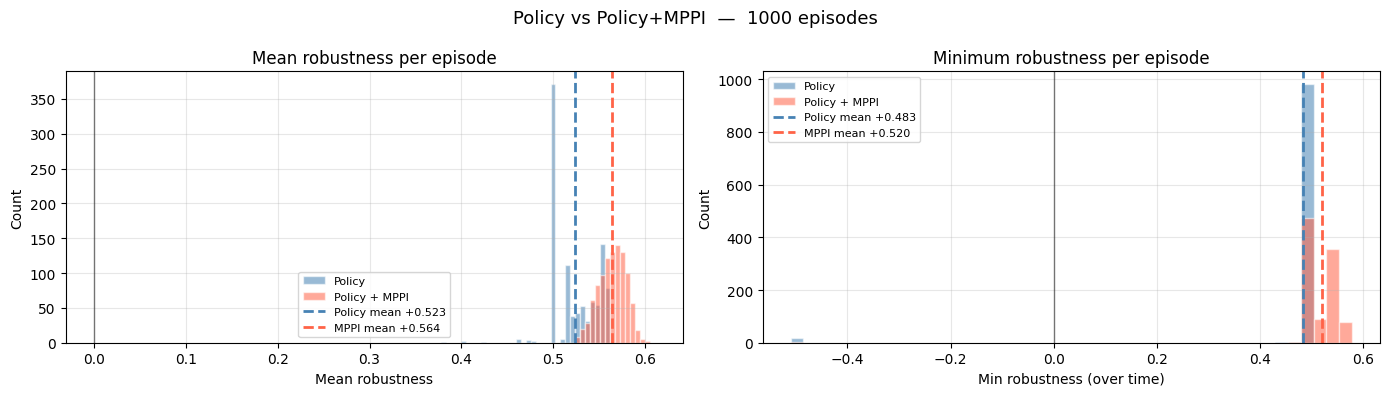

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
all_vals = np.concatenate([base_mean_robs, mppi_mean_robs])
bins = np.linspace(all_vals.min() - 0.01, all_vals.max() + 0.01, 45)

for ax, data_b, data_m, title, xlabel in [
    (axes[0], base_mean_robs, mppi_mean_robs,
     'Mean robustness per episode', 'Mean robustness'),
    (axes[1], base_min_robs,  mppi_min_robs,
     'Minimum robustness per episode', 'Min robustness (over time)'),
]:
    bins_ax = np.linspace(
        min(data_b.min(), data_m.min()) - 0.01,
        max(data_b.max(), data_m.max()) + 0.01, 45
    )
    ax.hist(data_b, bins=bins_ax, alpha=0.55, color='steelblue',
            edgecolor='white', label='Policy')
    ax.hist(data_m, bins=bins_ax, alpha=0.55, color='tomato',
            edgecolor='white', label='Policy + MPPI')
    ax.axvline(data_b.mean(), color='steelblue', lw=2, linestyle='--',
               label=f'Policy mean {data_b.mean():+.3f}')
    ax.axvline(data_m.mean(), color='tomato', lw=2, linestyle='--',
               label=f'MPPI mean {data_m.mean():+.3f}')
    ax.axvline(0, color='black', lw=1, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'Policy vs Policy+MPPI  —  {n_eval_episodes} episodes', fontsize=13)
plt.tight_layout()
plt.show()

## Per-Timestep Robustness Profile

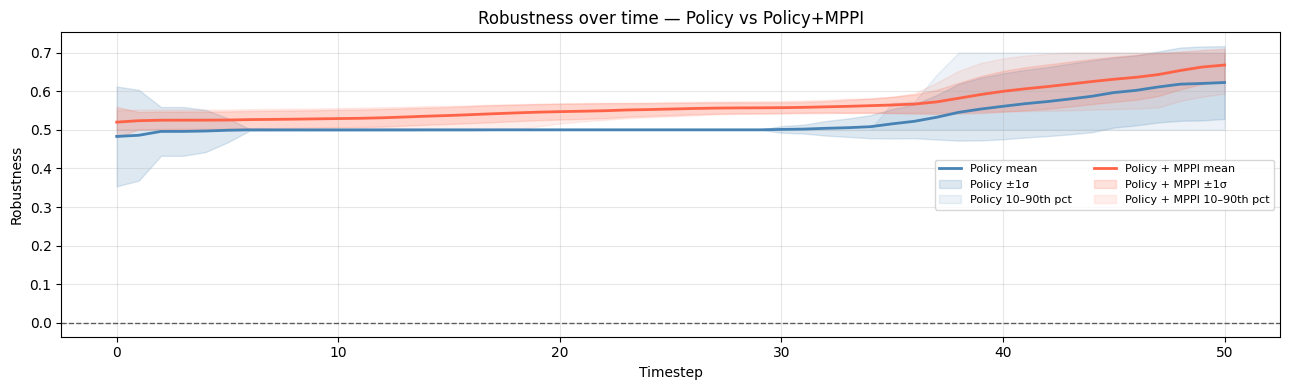

In [10]:
T_rob   = base_robs_time.shape[1]   # spec look-ahead truncates T+1 → T_rob
t_axis  = np.arange(T_rob)

fig, ax = plt.subplots(figsize=(13, 4))

for data, color, label in [
    (base_robs_time, 'steelblue', 'Policy'),
    (mppi_robs_time, 'tomato',    'Policy + MPPI'),
]:
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    p10  = np.percentile(data, 10, axis=0)
    p90  = np.percentile(data, 90, axis=0)
    ax.plot(t_axis, mean, lw=2, color=color, label=f'{label} mean')
    ax.fill_between(t_axis, mean - std, mean + std,
                    alpha=0.18, color=color, label=f'{label} ±1σ')
    ax.fill_between(t_axis, p10, p90,
                    alpha=0.10, color=color, label=f'{label} 10–90th pct')

ax.axhline(0, color='black', lw=1, alpha=0.6, linestyle='--')
ax.set_title('Robustness over time — Policy vs Policy+MPPI')
ax.set_xlabel('Timestep')
ax.set_ylabel('Robustness')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Episode-Level Improvement Scatter

Each point is one episode. Points **above** the diagonal mean MPPI improved robustness.

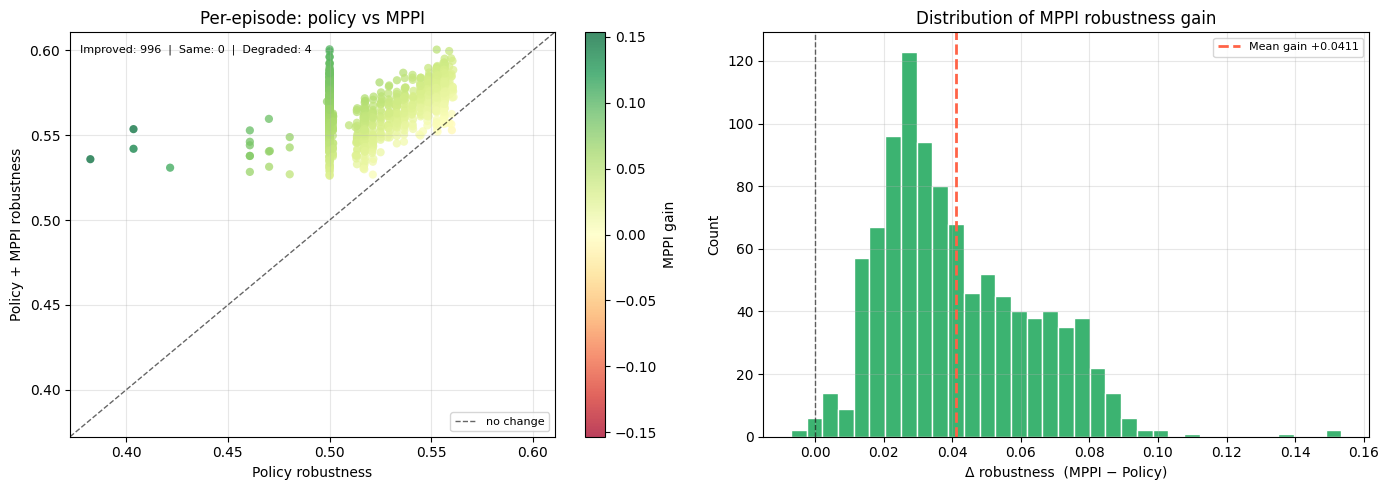

In [11]:
delta = mppi_mean_robs - base_mean_robs
improved  = (delta > 0).sum()
unchanged = (delta == 0).sum()
degraded  = (delta < 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
sc = ax.scatter(base_mean_robs, mppi_mean_robs,
                c=delta, cmap='RdYlGn', vmin=-abs(delta).max(), vmax=abs(delta).max(),
                s=35, alpha=0.75, edgecolors='none')
lim = [min(base_mean_robs.min(), mppi_mean_robs.min()) - 0.01,
       max(base_mean_robs.max(), mppi_mean_robs.max()) + 0.01]
ax.plot(lim, lim, 'k--', lw=1, alpha=0.6, label='no change')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Policy robustness')
ax.set_ylabel('Policy + MPPI robustness')
ax.set_title('Per-episode: policy vs MPPI')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='MPPI gain')
ax.text(0.02, 0.97,
        f'Improved: {improved}  |  Same: {unchanged}  |  Degraded: {degraded}',
        transform=ax.transAxes, va='top', fontsize=8)

# Gain histogram
ax = axes[1]
ax.hist(delta, bins=35, color='mediumseagreen', edgecolor='white')
ax.axvline(0, color='black', lw=1, alpha=0.6, linestyle='--')
ax.axvline(delta.mean(), color='tomato', lw=2, linestyle='--',
           label=f'Mean gain {delta.mean():+.4f}')
ax.set_title('Distribution of MPPI robustness gain')
ax.set_xlabel('Δ robustness  (MPPI − Policy)')
ax.set_ylabel('Count')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Success Rate Comparison

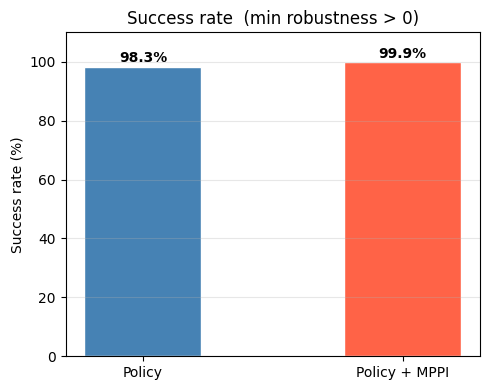

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
labels  = ['Policy', 'Policy + MPPI']
values  = [base_success, mppi_success]
colors  = ['steelblue', 'tomato']
bars    = ax.bar(labels, values, color=colors, edgecolor='white', width=0.45)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Success rate (%)')
ax.set_title('Success rate  (min robustness > 0)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
## Save Results to Disk

In [ ]:
import pandas as pd

# ── Per-episode scalar summary ────────────────────────────────────────────────
best_mean_robs = np.maximum(policy_mean_robs, mppi_mean_robs)   # best-of, for convenience
best_min_robs  = np.maximum(policy_min_robs,  mppi_min_robs)

df = pd.DataFrame({
    'episode':            np.arange(n_eval_episodes),
    # Baseline (batched rollout)
    'base_mean_rob':      base_mean_robs,
    'base_min_rob':       base_min_robs,
    'base_success':       base_min_robs > 0,
    # Policy warm-start (open-loop, per-episode)
    'policy_mean_rob':    policy_mean_robs,
    'policy_min_rob':     policy_min_robs,
    'policy_success':     policy_min_robs > 0,
    # MPPI-refined
    'mppi_mean_rob':      mppi_mean_robs,
    'mppi_min_rob':       mppi_min_robs,
    'mppi_success':       mppi_min_robs > 0,
    # Derived
    'mppi_gain':          mppi_mean_robs - policy_mean_robs,   # >0 means MPPI helped
    'mppi_better':        mppi_mean_robs > policy_mean_robs,
    'best_mean_rob':      best_mean_robs,
    'best_min_rob':       best_min_robs,
    'best_success':       best_min_robs > 0,
})

# ── Per-timestep robustness traces (wide format) ──────────────────────────────
T_rob = base_robs_time.shape[1]
for t in range(T_rob):
    df[f'base_rob_t{t}']   = base_robs_time[:, t]
    df[f'policy_rob_t{t}'] = policy_robs_time[:, t]
    df[f'mppi_rob_t{t}']   = mppi_robs_time[:, t]

# ── Save ──────────────────────────────────────────────────────────────────────
csv_path = 'evaluation_results.csv'
df.to_csv(csv_path, index=False)

print(f'Saved {len(df)} episodes × {len(df.columns)} columns  →  {csv_path}')
print()
print(df[['base_mean_rob', 'policy_mean_rob', 'mppi_mean_rob',
          'best_mean_rob', 'mppi_gain', 'mppi_better']].describe())
